## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [44]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
csv_file = 'shopping_trends.csv'
df = pd.read_csv(csv_file)
print('load file: ', csv_file)
df.head()

load file:  shopping_trends.csv


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [46]:
# TODO: check the dataset size with df.shape
# print('so hang: ', df.shape[0])
# print('so cot: ', df.shape[1])
df.shape

(3900, 19)

In [47]:
# TODO: drop the Customer ID column  
df = df.drop(columns='Customer ID')

In [48]:
df

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [49]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   str    
 2   Item Purchased            3900 non-null   str    
 3   Category                  3900 non-null   str    
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   str    
 6   Size                      3900 non-null   str    
 7   Color                     3900 non-null   str    
 8   Season                    3900 non-null   str    
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   str    
 11  Payment Method            3900 non-null   str    
 12  Shipping Type             3900 non-null   str    
 13  Discount Applied          3900 non-null   str    
 14  Promo Code Used    

In [50]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [51]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [52]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [53]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
# male_df = ?
# female_df = ?
male_df = df[df['Gender']=='Male']
female_df = df[df['Gender']=='Female']

In [54]:
male_df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [55]:
female_df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
2652,23,Female,Shorts,Clothing,20,Maryland,L,Cyan,Summer,3.3,No,Debit Card,2-Day Shipping,No,No,46,Credit Card,Monthly
2653,67,Female,Blouse,Clothing,36,Wisconsin,L,Lavender,Fall,4.8,No,Credit Card,Express,No,No,24,Venmo,Every 3 Months
2654,23,Female,Coat,Outerwear,70,Idaho,S,Pink,Fall,4.1,No,Debit Card,Next Day Air,No,No,4,PayPal,Annually
2655,26,Female,Sunglasses,Accessories,83,Wyoming,M,Gray,Summer,3.4,No,Credit Card,Standard,No,No,2,Credit Card,Fortnightly
2656,52,Female,Shorts,Clothing,76,Indiana,L,Yellow,Winter,3.6,No,Bank Transfer,Express,No,No,29,Bank Transfer,Fortnightly


## **EDA**

### **Item Purchased**

In [56]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
male_df['Item Purchased'].value_counts().reset_index()

,Item Purchased,count
0,Pants,123
1,Jewelry,119
2,Sweater,114
3,Coat,114
4,Dress,114
5,Scarf,112
6,Shirt,110
7,Shorts,109
8,Skirt,109
9,Jacket,109


In [57]:
female_df['Item Purchased'].value_counts().reset_index()

,Item Purchased,count
0,Blouse,66
1,Sandals,59
2,Shirt,59
3,Handbag,58
4,Socks,58
5,Sunglasses,56
6,Belt,55
7,Jacket,54
8,Dress,52
9,Jewelry,52


In [58]:
df['Item Purchased'].value_counts().reset_index()

,Item Purchased,count
0,Blouse,171
1,Pants,171
2,Jewelry,171
3,Shirt,169
4,Dress,166
5,Sweater,164
6,Jacket,163
7,Coat,161
8,Sunglasses,161
9,Belt,161


In [61]:
top_df = df['Item Purchased'].value_counts().head(10).reset_index()
top_df.columns = ['item', 'count']

In [62]:
top_df

,item,count
0,Blouse,171
1,Pants,171
2,Jewelry,171
3,Shirt,169
4,Dress,166
5,Sweater,164
6,Jacket,163
7,Coat,161
8,Sunglasses,161
9,Belt,161


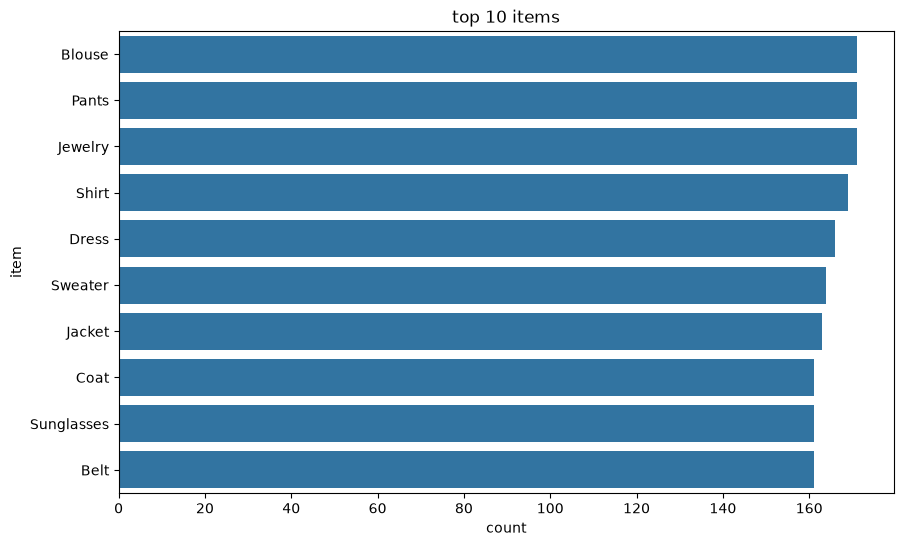

In [67]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_df,
    legend=False, #khong hien bang chu thich
    x='count',
    y='item'
)
plt.title('top 10 items')
plt.xlabel('count')
plt.ylabel('item')
plt.show()

In [68]:
top_m_df = male_df['Item Purchased'].value_counts().head(10).reset_index()
top_m_df.columns = ['items','count']

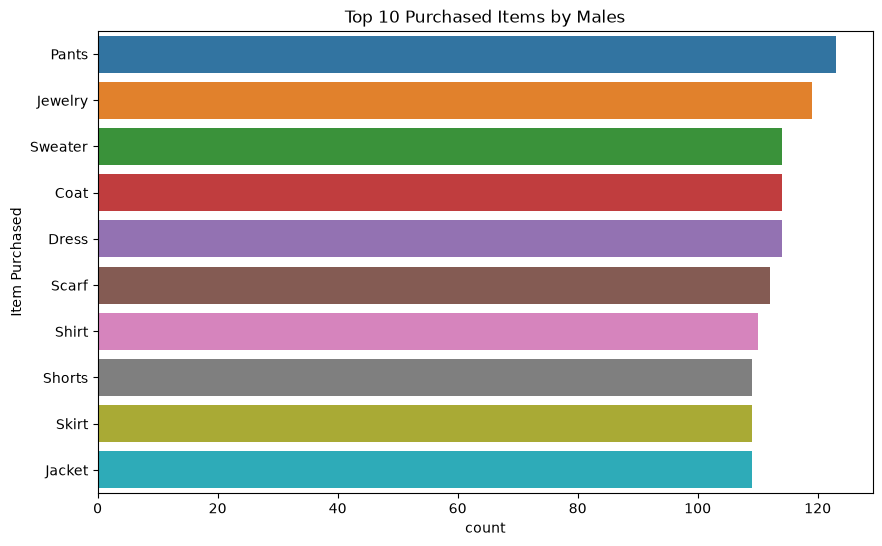

In [ ]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data= top_m_df,
    legend=False,
    x='count',
    y='items',
    hue='items' #dung items de phan mau
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [72]:
top_item_f = female_df['Item Purchased'].value_counts().reset_index()

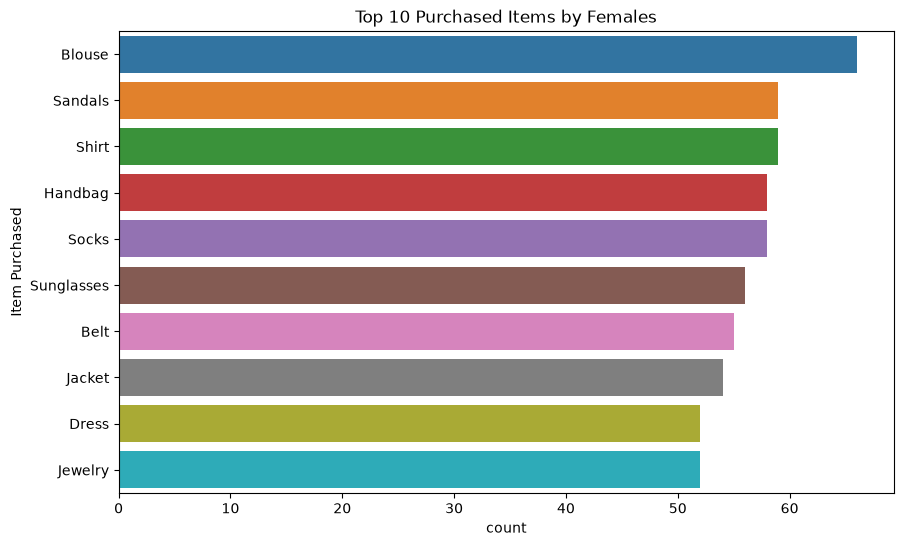

In [77]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_f.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [78]:
# TODO: count Size with value_counts() for all customers
df['Size'].value_counts()


Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [79]:
# TODO: count Size with value_counts() for male_df and female_df
male_df['Size'].value_counts()

Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64

In [80]:
female_df['Size'].value_counts()

Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64

### **Category**

In [81]:
# TODO: count Category with value_counts().reset_index() for all customers
ctg = df['Category'].value_counts().reset_index()

In [82]:
ctg

,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [83]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
male_df['Size'].value_counts().reset_index()

,Size,count
0,M,1165
1,L,716
2,S,476
3,XL,295


In [84]:
female_df['Size'].value_counts().reset_index()

,Size,count
0,M,590
1,L,337
2,S,187
3,XL,134


In [91]:
male_ctg = male_df['Category'].value_counts().reset_index()

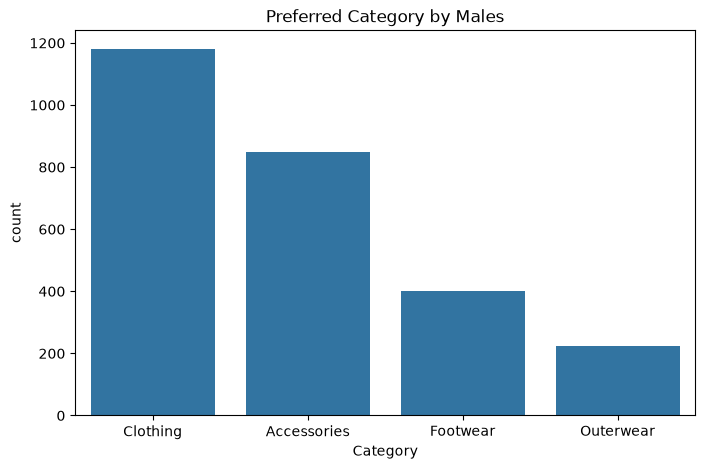

In [92]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data= male_ctg,
    x= 'Category',
    y= 'count',
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

In [93]:
female_ctg = female_df['Category'].value_counts().reset_index()

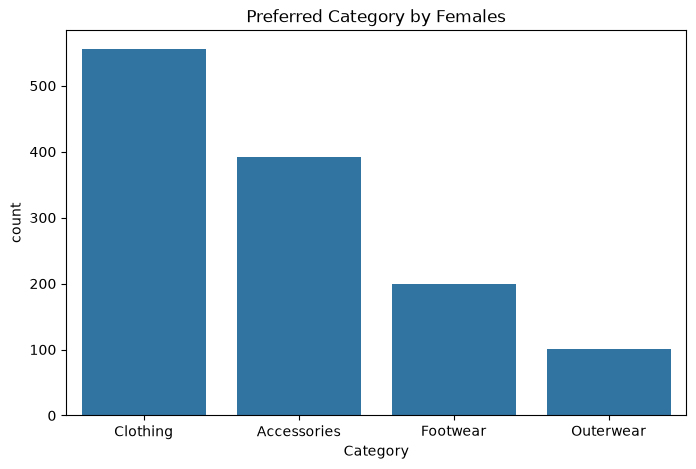

In [94]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
   data= female_ctg,
   x= 'Category',
   y= 'count'
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

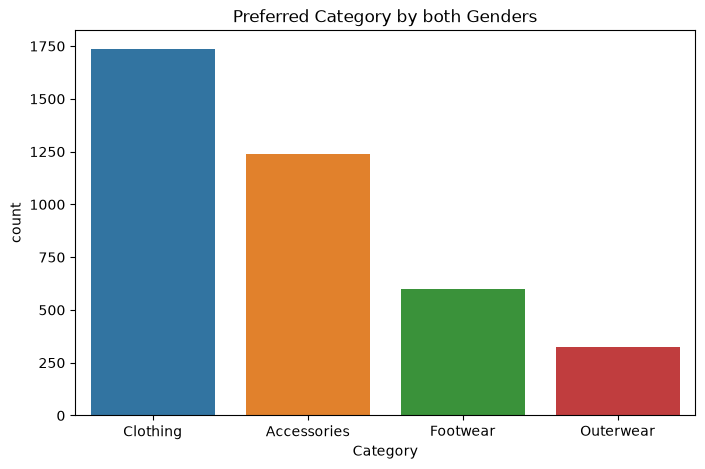

In [95]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.show()


In [96]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())


# TODO: create waffle_data_f from female_df['Category'].value_counts()
waffle_data_f = dict(female_df['Category'].value_counts())

In [97]:
waffle_data_f

{'Clothing': np.int64(556),
 'Accessories': np.int64(392),
 'Footwear': np.int64(199),
 'Outerwear': np.int64(101)}

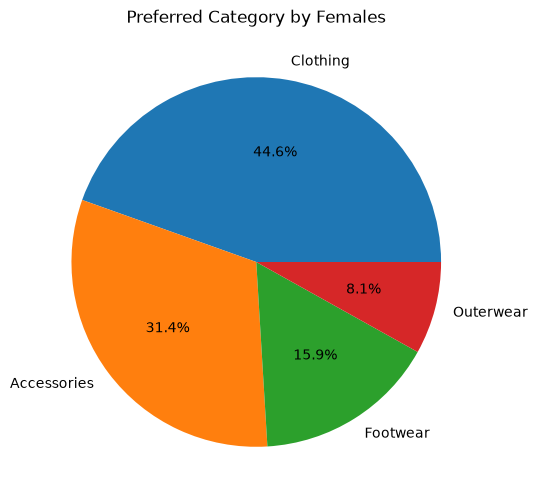

In [98]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
   waffle_data_f.values(),
   labels=waffle_data_f.keys(),
   autopct='%1.1f%%'
)
plt.title("Preferred Category by Females")
plt.show()

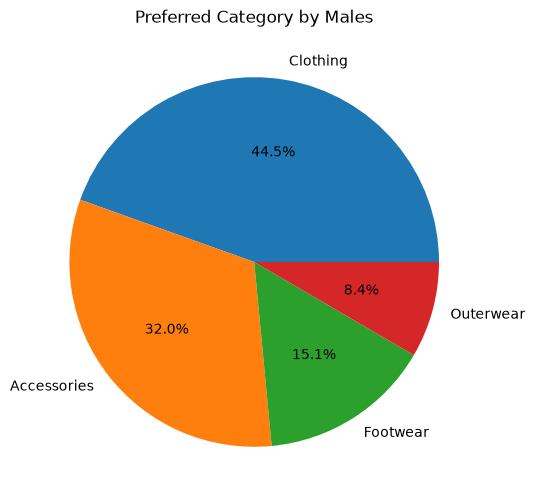

In [99]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show() 

### **Review ratings**

In [100]:
# TODO: filter female Clothing rows, then mean of Review Rating
cr_f = df[(df['Gender']=='Female') & (df['Category']=='Clothing')]
avg_cr_f = cr_f['Review Rating'].mean()

In [102]:
# TODO: filter male Clothing rows, then mean of Review Rating
cr_m = df[(df['Gender']=='Male') & (df['Category']=='Clothing')]
avg_cr_m = cr_m['Review Rating'].mean()

In [104]:
avg_cr_m, avg_cr_f

(np.float64(3.7319220999153258), np.float64(3.7044964028776977))

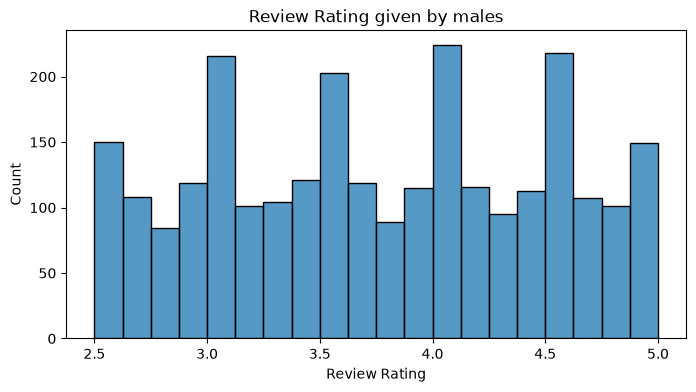

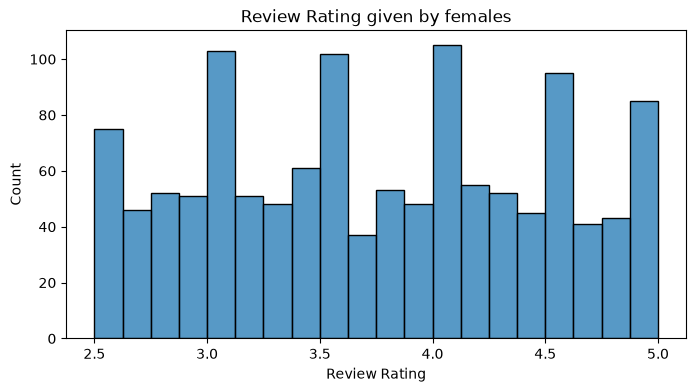

In [105]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show(),
# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females")
plt.show()

In [107]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
cr_m['Review Rating'].value_counts()

Review Rating
3.7    61
3.4    59
2.7    55
2.9    55
4.0    52
4.2    52
3.9    52
3.3    49
3.0    49
4.9    48
4.1    48
3.5    48
3.1    46
4.7    46
4.6    46
3.6    46
4.8    46
2.6    45
4.3    45
4.4    43
3.2    41
2.8    41
3.8    39
4.5    36
2.5    17
5.0    16
Name: count, dtype: int64

### **Purchase Amount (USD)**

In [109]:
male_df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [111]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()

# # TODO: sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()

In [112]:
m_tpa, f_tpa

(np.int64(157890), np.int64(75191))

mac dinh barplot tinh mean

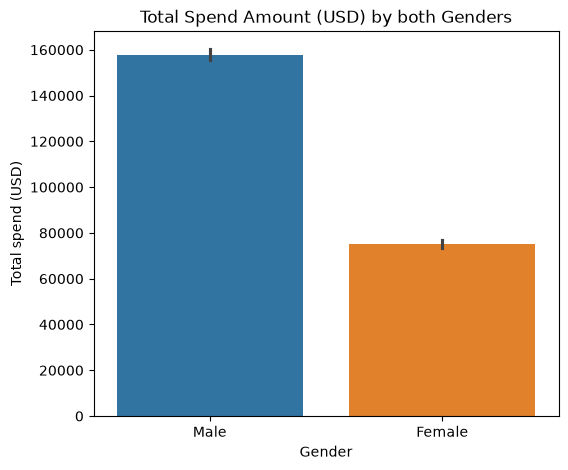

In [118]:
# TODO: plot total spend by gender with sns.barplot()
plt.figure(figsize=(6, 5))
sns.barplot(
    data= df,
    x= 'Gender',
    y= 'Purchase Amount (USD)',
    hue= 'Gender',
    estimator= 'sum',
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [119]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category']=='Accessories']
cf_f = female_df[female_df['Category']=='Footwear']
co_f = female_df[female_df['Category']=='Outerwear']

In [120]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category']=='Accessories']
cf_m = male_df[male_df['Category']=='Footwear']
co_m = male_df[male_df['Category']=='Outerwear']

In [125]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = df['Promo Code Used'].value_counts().to_dict()

In [126]:
pcu

{'No': 2223, 'Yes': 1677}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

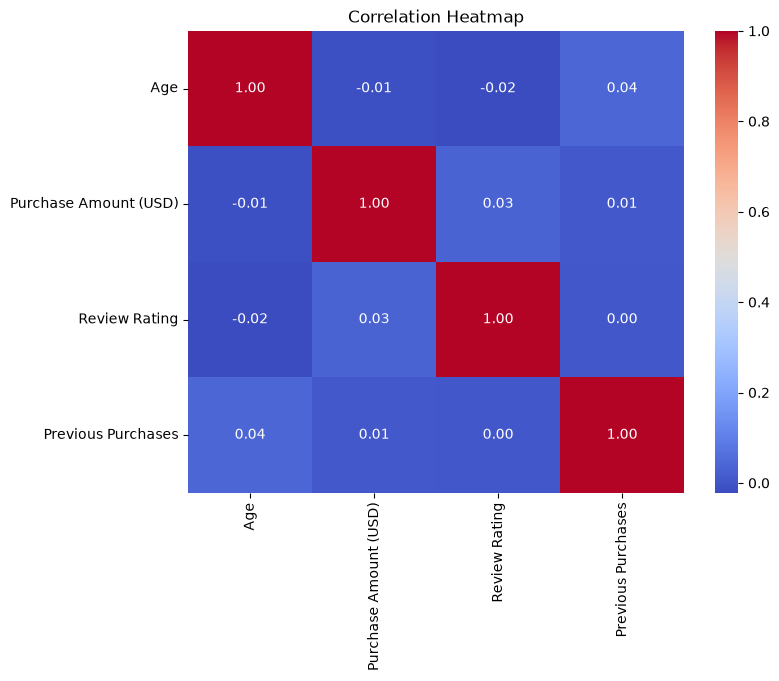

In [ ]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr_df = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_df,
    annot=True, #hien thi so tren o
    cmap="coolwarm",
    fmt=".2f" #hien thi so voi 2 chu so thap phan
)

plt.title("Correlation Heatmap")
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [128]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [130]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 5.2 MB/s eta 0:00:02
   -------------------------------------- - 8.1/8.4 MB 31.2 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 29.3 MB/s  0:00:00

   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwh

[[]] -> tra ve dataframe

In [131]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df['Amount_minmax'] = MinMaxScaler().fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = StandardScaler().fit_transform(df[['Age']])
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [132]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(
    df['Purchase Amount (USD)'],
    bins=[0, 50, 100, float('inf')],
    labels=['low', 'medium', 'high']
)
df['Amount_bin'].value_counts()

Amount_bin
medium    2386
low       1514
high         0
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- Đối với nam giới: mặt hàng phổ biến nhất là 'Pants', thuộc danh mục 'Clothing'.
  Đối với nữ giới: mặt hàng phổ biến nhất là 'Blouse', thuộc danh mục 'Clothing'.
- Clothing là một trong những danh mục phổ biến ở cả nam và nữ, bên cạnh các danh mục như Accessories, Footwear và Outerwear.
- Tổng số tiền chi tiêu của nam và nữ tương đối gần nhau, mặc dù một nhóm có tổng chi tiêu cao hơn nhóm còn lại.
- Review Rating giữa nam và nữ khá tương đồng, không có sự chênh lệch lớn về mức đánh giá.
- Promo Code chỉ được sử dụng trong một phần số giao dịch, trong khi một số lượng đáng kể khách hàng không sử dụng mã khuyến mãi.

Caveat: correlation is not causation.